In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [3]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [4]:
print(performance.columns)

print(performance.head())

print(benchmark.columns)

print(benchmark.head())

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct       

Daily Returns + Distribution

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


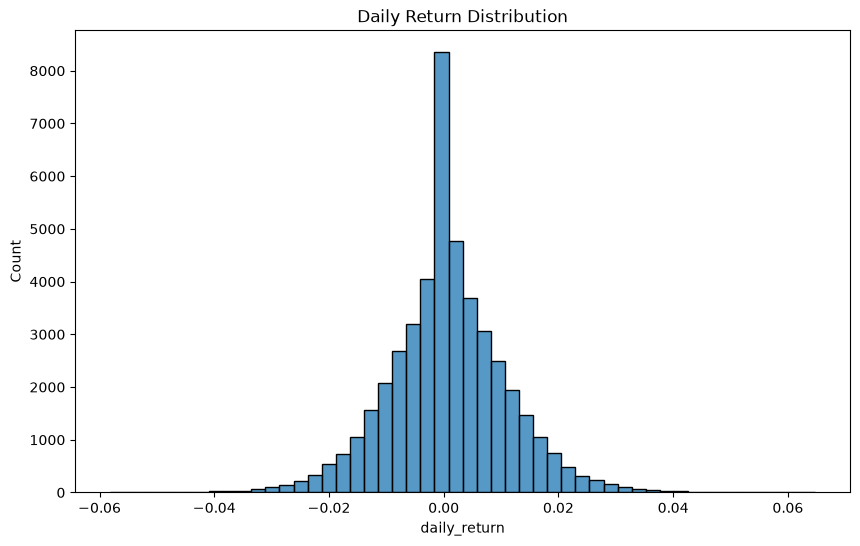

In [5]:
# convert date

nav["date"] = pd.to_datetime(nav["date"])


# sort values

nav = nav.sort_values(

    ["amfi_code", "date"]
)


# calculate daily return

nav["daily_return"] = nav.groupby(

    "amfi_code"

)["nav"].pct_change()


print(nav.head())


# distribution plot

plt.figure(figsize=(10,6))

sns.histplot(

    nav["daily_return"],

    bins=50
)

plt.title("Daily Return Distribution")

plt.savefig("../charts/daily_return_distribution.png")

plt.show()

CAGR (1Y, 3Y, 5Y)

In [6]:
def cagr(start,end,years):

    return ((end/start)**(1/years))-1


cagr_result = []


for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"]==code]

    df = df.sort_values("date")

    start = df.iloc[0]["nav"]

    end = df.iloc[-1]["nav"]

    cagr_1 = cagr(start,end,1)

    cagr_3 = cagr(start,end,3)

    cagr_5 = cagr(start,end,5)

    cagr_result.append(

        [code,cagr_1,cagr_3,cagr_5]
    )


cagr_df = pd.DataFrame(

    cagr_result,

    columns=[

        "amfi_code",

        "cagr_1yr",

        "cagr_3yr",

        "cagr_5yr"
    ]
)


print(cagr_df.head())

   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr
0     100016  0.121336  0.038912  0.023168
1     100025  0.211552  0.066058  0.039127
2     100033  2.185142  0.471328  0.260741
3     101206  1.534562  0.363435  0.204427
4     101207  0.399496  0.118555  0.069533


Sharpe Ratio

In [7]:
rf = 0.065

sharpe = []


for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"]==code]

    rp = df["daily_return"].mean()*252

    std = df["daily_return"].std()

    ratio = (rp-rf)/std*np.sqrt(252)

    sharpe.append(

        [code,ratio]
    )


sharpe_df = pd.DataFrame(

    sharpe,

    columns=[

        "amfi_code",

        "sharpe_ratio"
    ]
)


sharpe_df["sharpe_rank"] = sharpe_df[

    "sharpe_ratio"

].rank(ascending=False)


print(sharpe_df.head())

   amfi_code  sharpe_ratio  sharpe_rank
0     100016    -50.782301         35.0
1     100025   -142.907888         39.0
2     100033    275.612083          7.0
3     101206    258.857759          9.0
4     101207     40.990514         28.0


Sortino Ratio

In [8]:
sortino = []


for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"]==code]

    negative = df[

        df["daily_return"]<0

    ]["daily_return"]


    downside_std = negative.std()

    rp = df["daily_return"].mean()*252

    ratio = (rp-rf)/downside_std*np.sqrt(252)


    sortino.append(

        [code,ratio]
    )


sortino_df = pd.DataFrame(

    sortino,

    columns=[

        "amfi_code",

        "sortino_ratio"
    ]
)


print(sortino_df.head())

   amfi_code  sortino_ratio
0     100016     -88.463960
1     100025    -237.338952
2     100033     460.941758
3     101206     453.489844
4     101207      69.714237


Alpha Beta Regression

(assuming benchmark has index_name + close_value)

In [9]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='str')


In [10]:
benchmark["date"] = pd.to_datetime(

    benchmark["date"]
)


# use Nifty100

nifty100 = benchmark[

    benchmark["index_name"]=="NIFTY100"
]


nifty100["benchmark_return"] = nifty100[

    "close_value"

].pct_change()


alpha_beta = []


for code in nav["amfi_code"].unique():

    fund = nav[

        nav["amfi_code"]==code
    ]


    merged = pd.merge(

        fund,

        nifty100,

        on="date"
    )


    merged = merged.dropna()


    slope,intercept,r,p,std = linregress(

        merged["benchmark_return"],

        merged["daily_return"]
    )


    alpha = intercept*252

    beta = slope


    alpha_beta.append(

        [code,alpha,beta]
    )


alpha_beta_df = pd.DataFrame(

    alpha_beta,

    columns=[

        "amfi_code",

        "alpha",

        "beta"
    ]
)


alpha_beta_df.to_csv(

    "alpha_beta.csv",

    index=False
)


print(alpha_beta_df.head())

   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


Maximum Drawdown

In [11]:
dd = []


for code in nav["amfi_code"].unique():

    df = nav[

        nav["amfi_code"]==code
    ]


    running_max = df["nav"].cummax()


    drawdown = (

        df["nav"]/running_max

    )-1


    worst = drawdown.min()


    dd.append(

        [code,worst]
    )


dd_df = pd.DataFrame(

    dd,

    columns=[

        "amfi_code",

        "max_drawdown"
    ]
)


print(dd_df.head())

   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469


Fund Scorecard
Use existing expense ratio from performance file.

In [12]:
score = cagr_df.merge(

    sharpe_df,

    on="amfi_code"
)


score = score.merge(

    alpha_beta_df,

    on="amfi_code"
)


score = score.merge(

    dd_df,

    on="amfi_code"
)


score = score.merge(

    performance[

        ["amfi_code","expense_ratio_pct"]

    ],

    on="amfi_code"
)